In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, NodeRFModel, NodeLSTMModel, GATv2Model, ClimateologyModel, SpatialGNNModel
from src.evaluation import Evaluator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1


config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    include_gisd        = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )       
data_orchestrator = DataOrchestrator(config).build()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23029856/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [5]:
n_epochs        = 25
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdataloader_1  = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
# graphdataloader_2  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('mesh_graph').construct_dataloaders()
# graphdataloader_3  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('geographical_neighbors1').construct_dataloaders()
# graphdataloader_4  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity1').construct_dataloaders()
# graphdataloader_5  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity2').construct_dataloaders()
# graphdataloader_6  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity3').construct_dataloaders()
# graphdataloader_7  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity4').construct_dataloaders()
# graphdataloader_8  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity5').construct_dataloaders()
# graphdataloader_9  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter14_1').construct_dataloaders()
# graphdataloader_10 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter14_2').construct_dataloaders()
# graphdataloader_11 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter14_3').construct_dataloaders()
# graphdataloader_12 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter14_4').construct_dataloaders()
# graphdataloader_13 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter24_1').construct_dataloaders()
# graphdataloader_14 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter24_2').construct_dataloaders()
# graphdataloader_15 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter24_3').construct_dataloaders()
# graphdataloader_16 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('static_commuter24_4').construct_dataloaders()

In [4]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata)
climateology.forecast('test')

ClimateologyModel(name='climateology_model')

## RF

In [9]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=100)
rf.train(verbose=2)
rf.forecast('test')

Training loss for horizon 0: RMSE = 0.6205, MAE = 0.2467
Validation loss for horizon 0: RMSE = 0.8397, MAE = 0.3677


NodeRFModel(name='NodeRFModel')

## LSTM


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))


Training epochs:  20%|█████████████████████████████▌                                                                                                                         | 49/250 [02:38<10:52,  3.24s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4958


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 456.46it/s]

Test loss: 0.7600


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

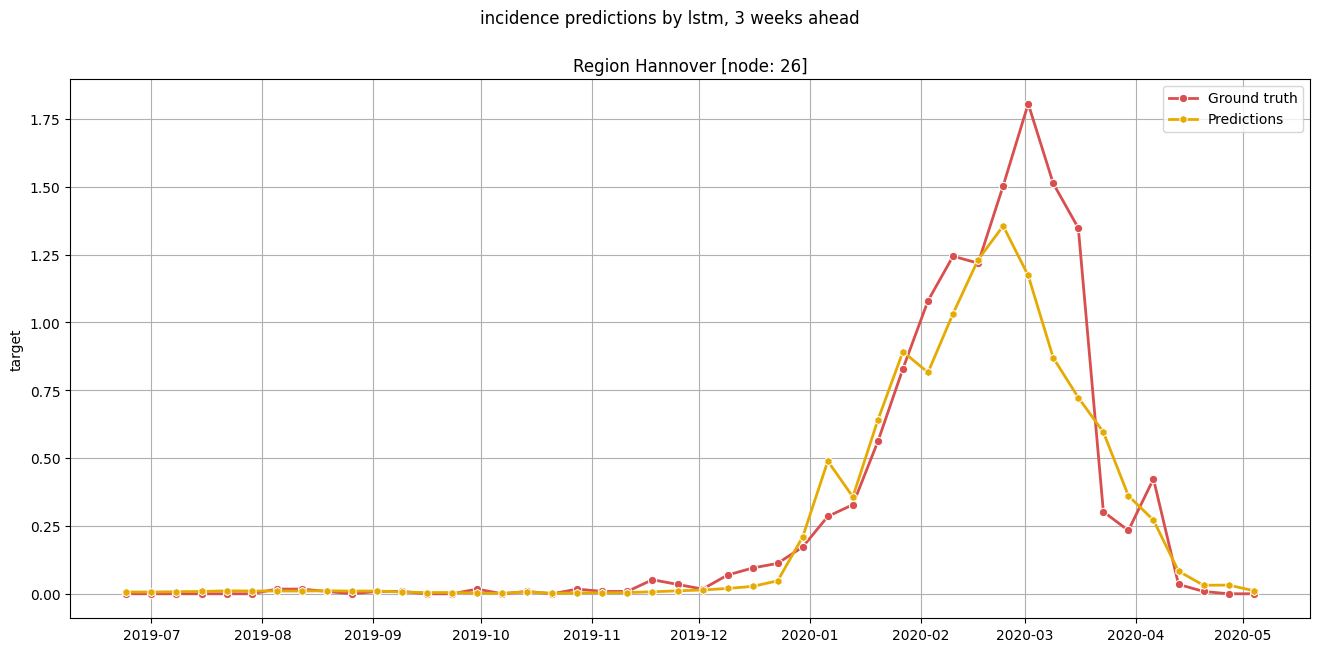

In [8]:
lstm = NodeLSTMModel(graphdataloader_1, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 0, show_loss=False)
lstm.forecast('test')
lstm.show_forecasts(26)

## GNNs

In [ ]:
# spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'gcn-identity_graph')
# spatial_model1.set_model_hparams()
# spatial_model1.set_global_hparams(**global_hparams)
# spatial_model1.train(verbose = 0, show_loss=False)
# spatial_model1.forecast('test')
# spatial_model1.show_forecasts(26)

# spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'gcn-boolean_neighbors')
# spatial_model2.set_model_hparams()
# spatial_model2.set_global_hparams(**global_hparams)
# spatial_model2.train(verbose = 0, show_loss=False)
# spatial_model2.forecast('test')
# spatial_model2.show_forecasts(26)


st1 = GATv2Model(graphdataloader_1, name = 'undertrained_gatv2')
st1.set_model_hparams()
st1.set_global_hparams(**global_hparams)
st1.train()
st1.forecast('test')
st1.show_forecasts(26)

# st2 = GATv2Model(graphdataloader_2, name = 'gatv2-2')
# st2.set_model_hparams()
# st2.set_global_hparams(**global_hparams)
# st2.train(verbose = 0, show_loss=False)
# st2.forecast('test')
# st2.show_forecasts(26)

# st3 = GATv2Model(graphdataloader_3, name = 'gatv2-3')
# st3.set_model_hparams()
# st3.set_global_hparams(**global_hparams)
# st3.train(verbose = 0, show_loss=False)
# st3.forecast('test')
# st3.show_forecasts(26)


# st4 = GATv2Model(graphdataloader_10, name = 'gatv2-10')
# st4.set_model_hparams()
# st4.set_global_hparams(**global_hparams)
# st4.train(verbose = 0, show_loss=False)
# st4.forecast('test')
# st4.show_forecasts(26)


# st5 = GATv2Model(graphdataloader_14, name = 'gatv2-14')
# st5.set_model_hparams()
# st5.set_global_hparams(**global_hparams)
# st5.train(verbose = 0, show_loss=False)
# st5.forecast('test')
# st5.show_forecasts(26)



In [ ]:
st1.save('my_trained_model')

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:07<00:00,  1.33s/it]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

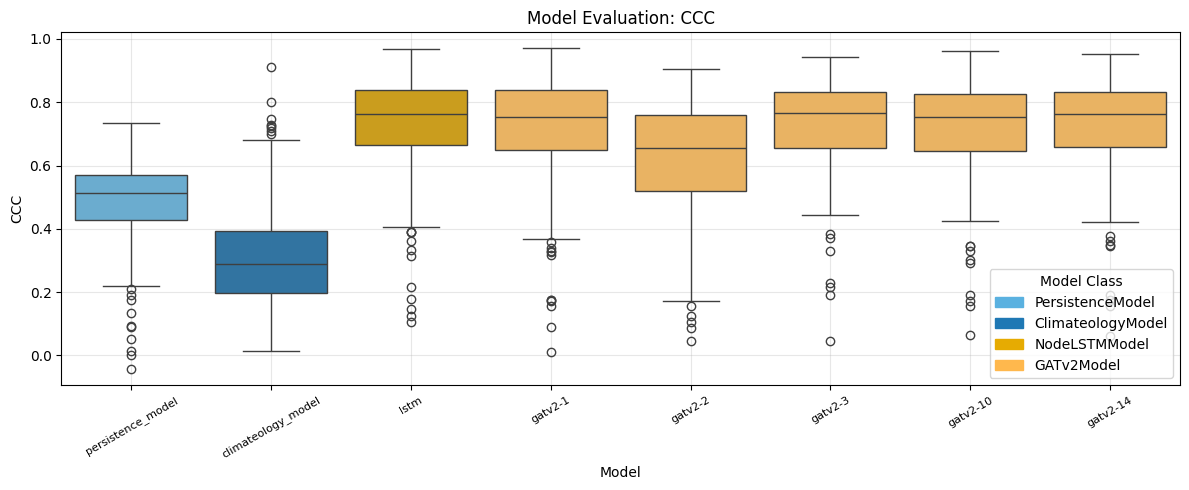

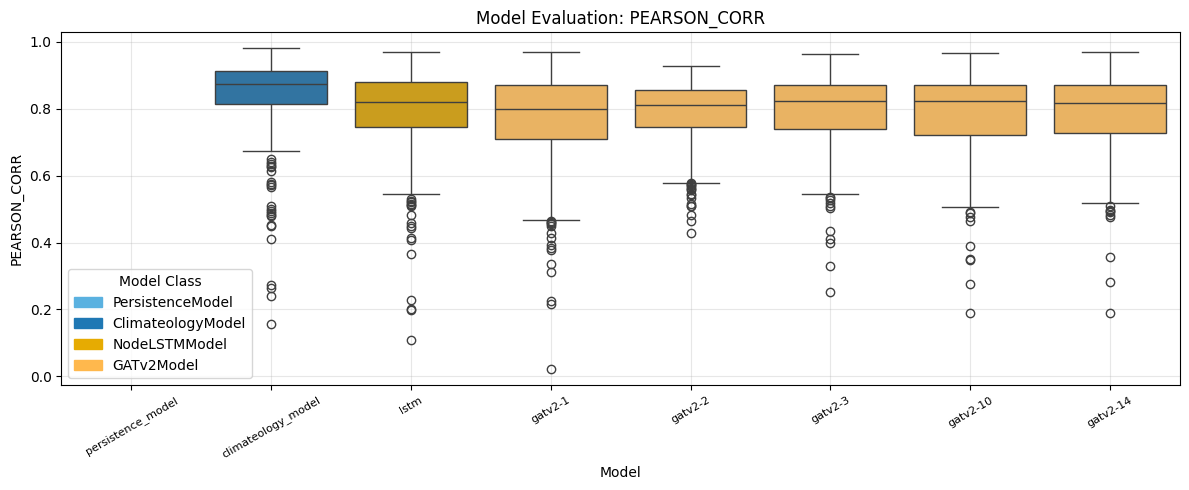

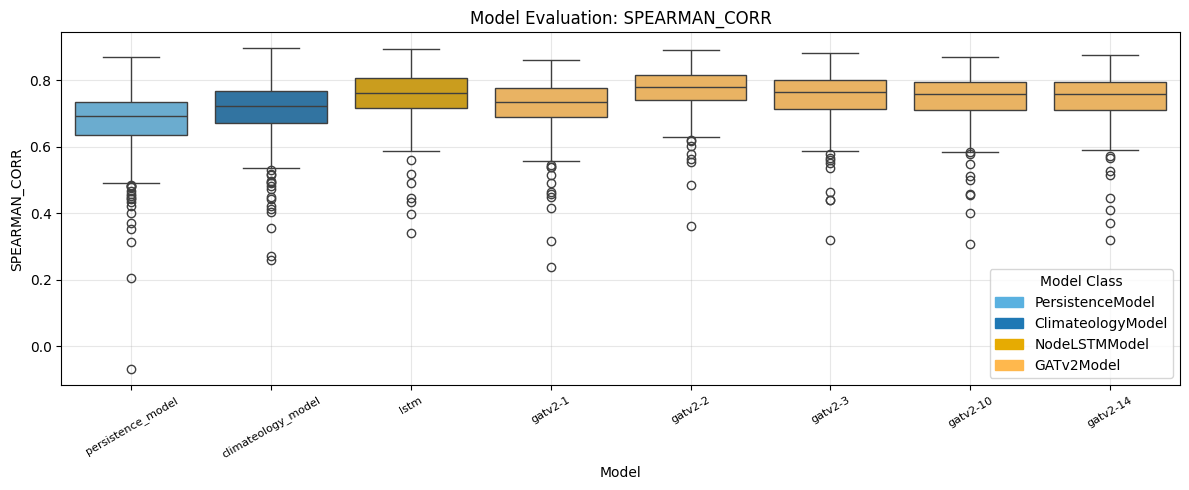

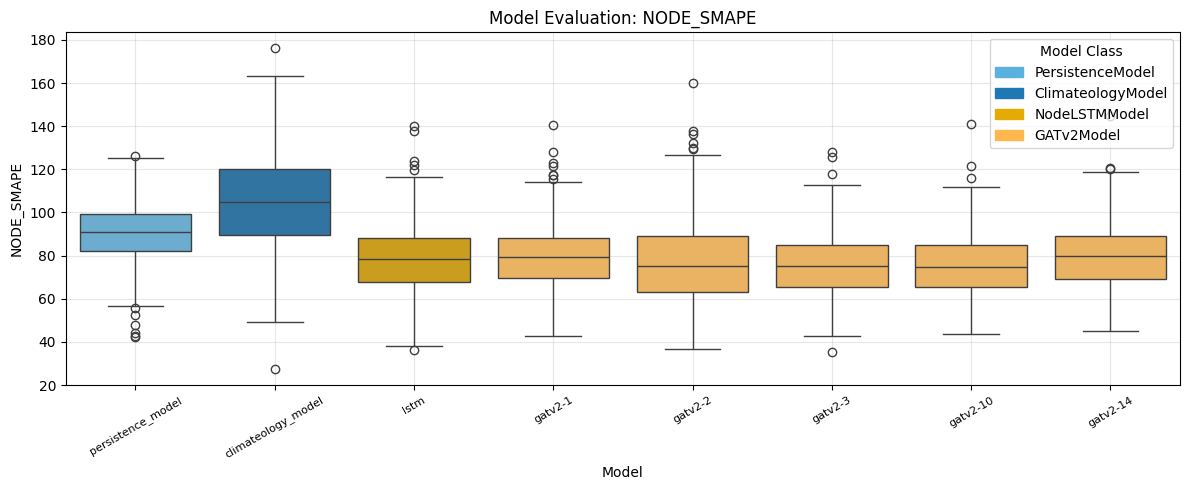

In [12]:
evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('pearson_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('spearman_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('node_smape', horizon = 'horizon_0', plot_type='box')